# End-to-End Mini Project: Real Estate Price Prediction (Azerbaijan)

## Checkpoint 2 — Full EDA + Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)

df = pd.read_csv("data/house_sale.csv")
print("Shape:", df.shape)
df.head()

Shape: (100775, 51)


,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,repair,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,total_price,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,hour_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,vipped,featured,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,92e82ea2-e1f3-4c2d-a284-151efd99281e,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/items/4521724,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...",3 450 AZN/m²,499999.0,AZN,Kamran,mülkiyyətçi,NaN,NaN,İzzət Nəbiyev küç.,40.358817,49.824092,yeniləndi: dünən 23:52,1155,05.10.2024,23:52,92e82ea2-e1f3-4c2d-a284-151efd99281e,NaN,Köhnə tikili,7 / 9,4.0,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,05.10.2024,23:56,Təmirli,NaN,NaN,NaN,NaN,NaN,https://bina.azstatic.com/uploads/f460x345/202...,505eaf81-6bc8-4094-9b00-aa82066548ee,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/items/4669294,2024-10-05 22:14:10.089116+00,"Biləcəridə Abidəyə yaxin 91,92,202 saylı marşr...",NaN,77000.0,AZN,Dasinmaz Emlak,vasitəçi (agent),NaN,NaN,Biləcəri qəs.,40.420897,49.807035,yeniləndi: 04 oktyabr 2024,218,04.10.2024,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,NaN,Həyət evi/Bağ evi,NaN,4.0,90 m²,1.3 sot,var,yoxdur,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,NaN,NaN,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,fa63b201-999d-43b5-a61a-778d9d79a6c6,55c36fb1-a3af-476e-ba17-a81f6795be8d,/items/4669293,2024-10-05 22:14:10.089116+00,Salam əleykum. \nİnşaatçılar metrosuna yaxın m...,NaN,92000.0,AZN,Məhəmməd,vasitəçi (agent),NaN,NaN,Mirzə Cabbar Məmmədzadə küç.,40.390293,49.802656,yeniləndi: 04 oktyabr 2024,190,04.10.2024,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,NaN,Həyət evi/Bağ evi,NaN,3.0,60 m²,0.1 sot,var,var,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/alqi-satqi?page=250,/items/4647811,2024-10-05 22:07:37.60613+00,95000.0,AZN,Qaraçuxur q.,130 m²,"Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,vipped,featured,NaN,Çıxarış var,İpoteka var,https://bina.azstatic.com/uploads/f460x345/202...,5db56980-05cc-4925-b55b-f58fb3f4d2b6,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/items/4647811,2024-10-05 22:14:10.089116+00,Barter maraqlidir üstünlük maşina verilir\nHər...,NaN,95000.0,AZN,Elçin,mülkiyyətçi,NaN,NaN,Qaraçuxur qəs.,40.393614,49.981553,yeniləndi: 04 oktyabr 2024,1314,04.10.2024,NaN,5db56980-05cc-4925-b55b-f58fb3f4d2b6,NaN,Obyekt,NaN,NaN,130 m²,NaN,var,var,var,5db56980-05cc-4925-b55b-f58fb3f4d2b6,/items/4647811,Suraxanı r.* Qaraçuxur q.
4,22d840df-9283-4112-bc71-7432511fc776,/alqi-satqi?page=250,/items/4638863,2024-10-05 22:07:37.60613+00,220000.0,AZN,Əhmədli m.,"3 otaqlı, 100 m², 15/16 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,NaN,NaN,Agentlik,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,d71cf9a9-86dd-4162-b540-6252a8659a09,22d840df-9283-4112-bc71-7432511fc776,/items/4638863,2024-10-05 22:14:10.089116+00,Əhmədli qəs. Qaçaq Nəbi küçəsi 3 otaga duzelm...

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100775 entries, 0 to 100774
Data columns (total 51 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id_x                 100775 non-null  object 
 1   rel_url              100775 non-null  object 
 2   estate_rel_url_x     100775 non-null  object 
 3   datetime_scrape_x    100775 non-null  object 
 4   price                100775 non-null  float64
 5   currency_x           100775 non-null  object 
 6   location             100775 non-null  object 
 7   attributes           100775 non-null  object 
 8   city_when            100775 non-null  object 
 9   city                 100775 non-null  object 
 10  day_x                100775 non-null  object 
 11  hour_x               100775 non-null  object 
 12  repair               81612 non-null   object 
 13  vip                  8596 non-null    object 
 14  featured             3149 non-null    object 
 15  products_label   

In [3]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


We look at the percentage of missing values per column before deciding what to do with each
one.

In [4]:
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)
null_pct

Binanın növü      99.85
featured          96.88
vip               91.47
Torpaq sahəsi     84.55
hour_y            84.49
İpoteka           67.31
mortgage          67.31
shop_name         28.54
shop_title        28.54
products_label    27.93
unit_price        24.59
Mərtəbə           24.59
bill_of_sale      21.05
repair            19.02
Otaq sayı          9.34
Təmir              5.95
owner_name         0.65
owner_title        0.65
description        0.26
dtype: float64

Several columns come in `_x` / `_y` pairs (`id_x`/`id_y`, `estate_rel_url_x`/`_y`,
`datetime_scrape_x`/`_y`, `day_x`/`_y`, `hour_x`/`_y`, `currency_x`/`_y`,
`estate_details_id_x`/`_y`). This is a strong signal that the data was produced by joining
two source tables (a "listing" table and a "details" table) on `estate_id`. That also
explains why some columns are exact duplicates of each other under different names. Let's
verify a few suspected duplicate pairs before deciding what to drop.

In [5]:
print("repair vs Təmir:")
print(pd.crosstab(df['repair'].isna(), df['Təmir'], dropna=False))
print()
print("bill_of_sale vs Çıxarış:")
print(pd.crosstab(df['bill_of_sale'].isna(), df['Çıxarış'], dropna=False))
print()
print("mortgage vs İpoteka:")
print(pd.crosstab(df['mortgage'].isna(), df['İpoteka'], dropna=False))

repair vs Təmir:
Təmir     var  yoxdur   NaN
repair                     
False   81612       0     0
True        0   13162  6001

bill_of_sale vs Çıxarış:
Çıxarış         var  yoxdur
bill_of_sale               
False         79565       0
True              0   21210

mortgage vs İpoteka:
İpoteka     var    NaN
mortgage              
False     32939      0
True          0  67836



The target is **`price`**. Two other columns look suspiciously close to it:

In [6]:
print("Correlation(price, total_price):", df['price'].corr(df['total_price']))
print("Rows where they match exactly:", (df['price'] == df['total_price']).mean())
df[['price', 'total_price', 'unit_price']].head()

Correlation(price, total_price): 0.999999999379206
Rows where they match exactly: 0.9998709997519226


,price,total_price,unit_price
0,499999.0,499999.0,3 450 AZN/m²
1,77000.0,77000.0,NaN
2,92000.0,92000.0,NaN
3,95000.0,95000.0,NaN
4,220000.0,220000.0,2 200 AZN/m²


`total_price` matches `price` in **99.99%** of rows — it's essentially the same column
under a different name. `unit_price` is price-per-m², i.e. it's *calculated directly from*
`price`. If either of these is left in the feature set, the model would just learn to copy
the target instead of learning real price drivers — this is exactly the kind of leakage the
task's quality checks warn about. **Both are dropped before modeling.**


In [7]:
print("Most expensive listings:")
print(df.nlargest(8, 'price')[['price', 'Sahə', 'Kateqoriya', 'city']])
print()
print("Cheapest listings:")
print(df.nsmallest(8, 'price')[['price', 'Sahə', 'Kateqoriya', 'city']])

Most expensive listings:
             price        Sahə   Kateqoriya  city
6605   600000000.0      200 m²  Yeni tikili  bakı
6942    60000000.0       50 m²  Yeni tikili  bakı
45825   40000000.0  200000 sot       Torpaq  bakı
72637   39000000.0     200 sot       Torpaq  bakı
8065    36000000.0     3000 m²       Obyekt  bakı
31276   36000000.0     3000 m²       Obyekt  bakı
34851   36000000.0     3000 m²       Obyekt  bakı
81161   36000000.0     3000 m²       Obyekt  bakı

Cheapest listings:
       price      Sahə         Kateqoriya  city
38666   11.0     89 m²             Obyekt  bakı
22304   73.0     90 m²        Yeni tikili  bakı
39775  127.0    150 m²  Həyət evi/Bağ evi  bakı
21745  250.0     30 m²  Həyət evi/Bağ evi  bakı
11322  400.0     86 m²        Yeni tikili  bakı
15608  400.0     86 m²        Yeni tikili  bakı
39396  700.0     65 m²       Köhnə tikili  bakı
8321   800.0  2500 sot             Torpaq  bakı


A **200 m² apartment for 600,000,000 AZN**, and listings priced at **11-100 AZN**, are
not real market prices — they're data-entry errors (extra zeros, misplaced decimals,
placeholder values), not legitimately expensive/cheap properties. Unlike the "cap but keep"
approach used for normal outliers, these are just bad rows and should be removed rather than
capped, otherwise they would distort both the EDA charts and the model.

We use fixed, business-reasoned thresholds (not statistics computed from the data) to filter
these out, which is safe to do **before** the train/test split — it's a data-quality rule,
not something learned from the target distribution:

In [8]:
before = len(df)
df = df[(df['price'] >= 1000) & (df['price'] <= 5_000_000)].copy()
after = len(df)
print(f"Removed {before - after} implausible-price rows ({(before-after)/before*100:.2f}% of data)")
print("New shape:", df.shape)

Removed 359 implausible-price rows (0.36% of data)
New shape: (100416, 51)


### 2.7 Applying the cleaning plan

In [9]:
df_clean = df.copy()

df_clean["is_shop"] = df_clean["shop_name"].notna().astype(int)

drop_cols = [
    "id_x", "id_y", "estate_id", "estate_details_id_x", "estate_details_id_y",
    "rel_url", "estate_rel_url_x", "estate_rel_url_y", "estate_rel_url", "img_url",
    "datetime_scrape_x", "datetime_scrape_y", "day_x", "day_y", "hour_x", "hour_y", "updated",
    "currency_x", "currency_y",
    "description", "attributes", "extra_info", "owner_name", "owner_title",
    "shop_name", "shop_title", "address", "location", "city_when",
    "Binanın növü",
    "total_price", "unit_price",
    "repair", "bill_of_sale", "mortgage",
]
df_clean = df_clean.drop(columns=drop_cols)

df_clean["area_sqm"] = df_clean["Sahə"].str.extract(r"([\d.]+)").astype(float)

df_clean["land_sot"] = df_clean["Torpaq sahəsi"].str.extract(r"([\d.]+)").astype(float)
df_clean["land_sot"] = df_clean["land_sot"].fillna(0)

floor_split = df_clean["Mərtəbə"].str.extract(r"(\d+)\s*/\s*(\d+)")
df_clean["floor"] = floor_split[0].astype(float)
df_clean["total_floors"] = floor_split[1].astype(float)

df_clean = df_clean.drop(columns=["Sahə", "Torpaq sahəsi", "Mərtəbə"])

for c in ["vip", "featured", "products_label"]:
    df_clean[c] = df_clean[c].fillna("yoxdur")
df_clean["Təmir"] = df_clean["Təmir"].fillna("naməlum")

print("Remaining nulls (left for the pipeline's imputer, computed on train only):")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print()
print("df_clean shape:", df_clean.shape)
df_clean.head()

Remaining nulls (left for the pipeline's imputer, computed on train only):
Otaq sayı        9077
İpoteka         67585
floor           24433
total_floors    24433
dtype: int64

df_clean shape: (100416, 18)


,price,city,vip,featured,products_label,lat,lng,views,Kateqoriya,Otaq sayı,Təmir,Çıxarış,İpoteka,is_shop,area_sqm,land_sot,floor,total_floors
0,499999.0,bakı,vipped,featured,yoxdur,40.358817,49.824092,1155,Köhnə tikili,4.0,var,var,NaN,0,145.0,0.0,7.0,9.0
1,77000.0,bakı,yoxdur,yoxdur,yoxdur,40.420897,49.807035,218,Həyət evi/Bağ evi,4.0,var,yoxdur,NaN,0,90.0,1.3,NaN,NaN
2,92000.0,bakı,yoxdur,yoxdur,yoxdur,40.390293,49.802656,190,Həyət evi/Bağ evi,3.0,var,var,NaN,0,60.0,0.1,NaN,NaN
3,95000.0,bakı,vipped,featured,yoxdur,40.393614,49.981553,1314,Obyekt,NaN,var,var,var,0,130.0,0.0,NaN,NaN
4,220000.0,bakı,yoxdur,yoxdur,Agentlik,40.390550,49.957675,240,Yeni tikili,3.0,var,var,NaN,1,100.0,0.0,15.0,16.0


The only columns with remaining nulls are genuinely numeric/continuous
(`Otaq sayı`, `İpoteka`, `floor`, `total_floors`) — these are imputed with the **median of
the training fold only**, inside the modeling pipeline (Section 3), so no information from
the test set leaks into the imputation.

IQR bounds: [-140,000, 620,000]
Still flagged by IQR: 7065 rows (7.04%) — legitimate expensive/cheap listings, not errors.


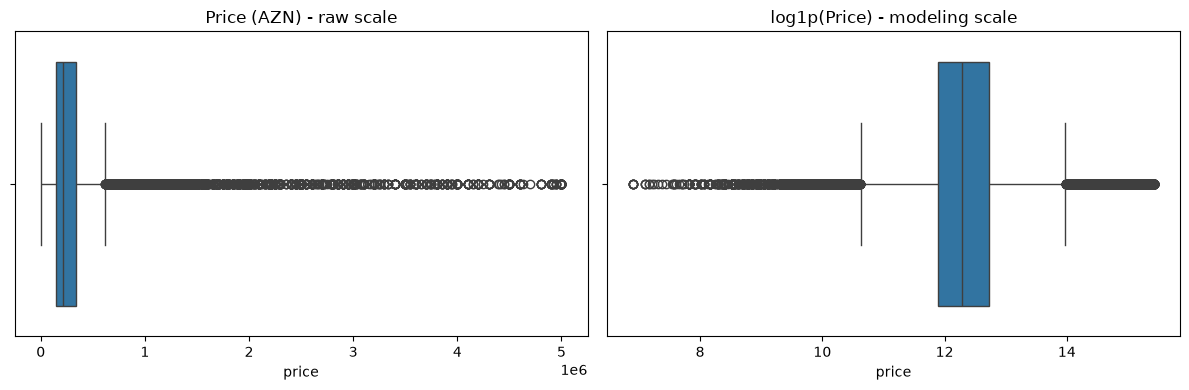

In [10]:
Q1 = df_clean["price"].quantile(0.25)
Q3 = df_clean["price"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
mild_outliers = df_clean[(df_clean["price"] < lower) | (df_clean["price"] > upper)]
print(f"IQR bounds: [{lower:,.0f}, {upper:,.0f}]")
print(f"Still flagged by IQR: {len(mild_outliers)} rows ({len(mild_outliers)/len(df_clean)*100:.2f}%) — legitimate expensive/cheap listings, not errors.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_clean["price"], ax=axes[0])
axes[0].set_title("Price (AZN) - raw scale")
sns.boxplot(x=np.log1p(df_clean["price"]), ax=axes[1])
axes[1].set_title("log1p(Price) - modeling scale")
plt.tight_layout()
plt.show()

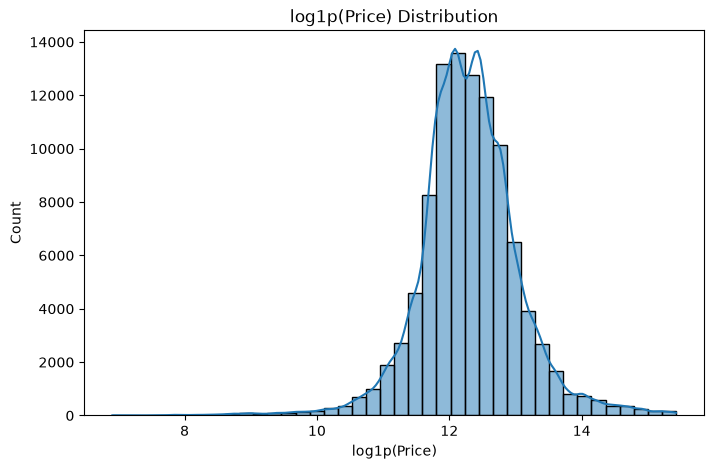

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df_clean["price"]), bins=40, kde=True)
plt.title("log1p(Price) Distribution")
plt.xlabel("log1p(Price)")
plt.show()

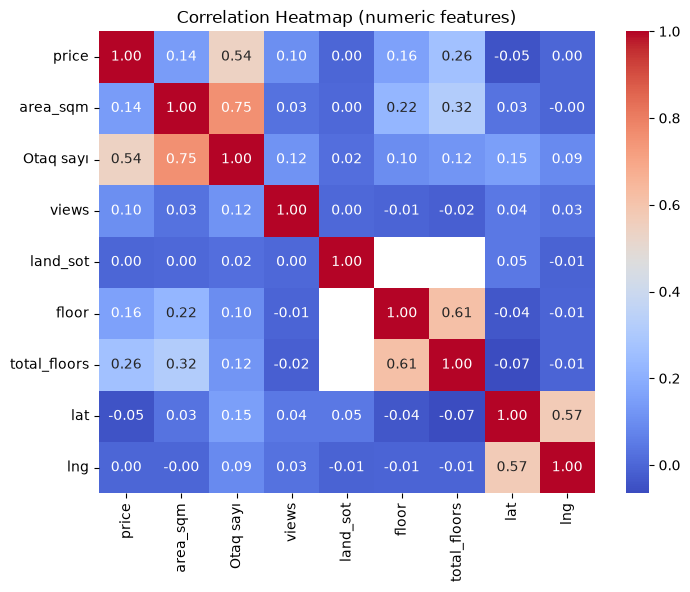

In [12]:
plt.figure(figsize=(8, 6))
num_cols_preview = ["price", "area_sqm", "Otaq sayı", "views", "land_sot", "floor", "total_floors", "lat", "lng"]
corr = df_clean[num_cols_preview].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (numeric features)")
plt.show()

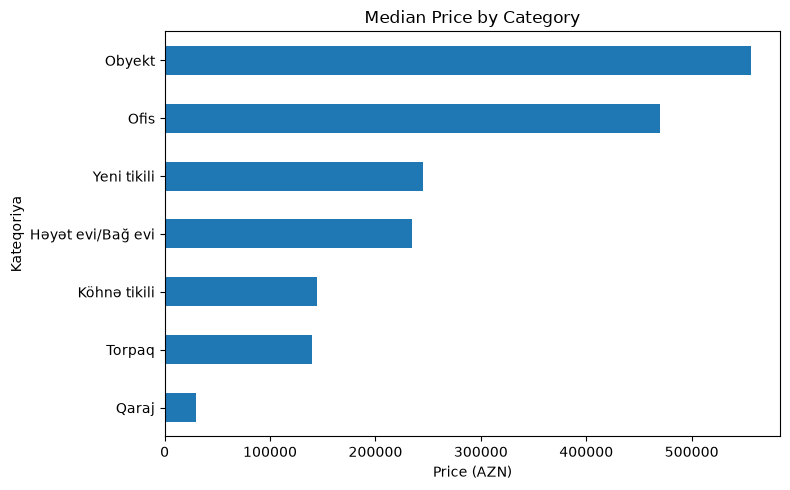

In [13]:
plt.figure(figsize=(8, 5))
df_clean.groupby("Kateqoriya")["price"].median().sort_values().plot(kind="barh")
plt.title("Median Price by Category")
plt.xlabel("Price (AZN)")
plt.tight_layout()
plt.show()

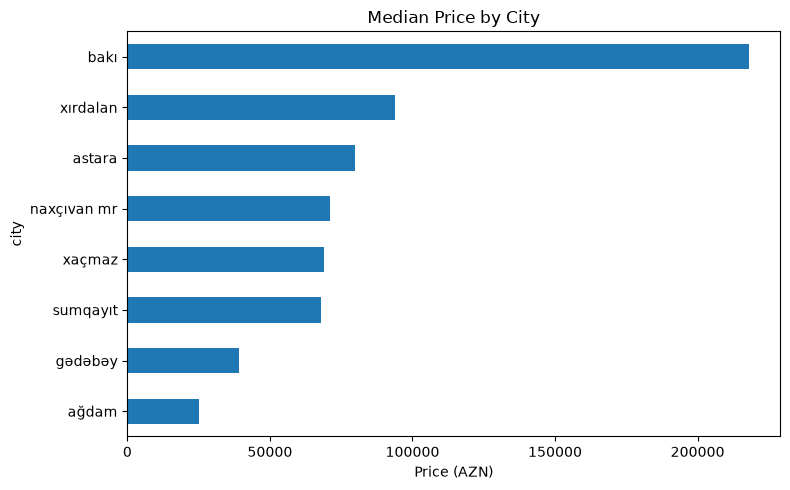

In [14]:
plt.figure(figsize=(8, 5))
df_clean.groupby("city")["price"].median().sort_values().plot(kind="barh")
plt.title("Median Price by City")
plt.xlabel("Price (AZN)")
plt.tight_layout()
plt.show()

## Checkpoint 3 — Comparing at least 3 Models (same CV, same metric)

We split into train/test **first**, and only ever look at `X_test` / `y_test` once, at the
very end (Checkpoint 5). All model comparison and tuning below uses **only** `X_train` /
`y_train`, evaluated with the same 5-fold cross-validation split and the same scoring
metric, so the comparison is fair.

In [15]:
y = df_clean["price"]
X = df_clean.drop(columns=["price"])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_log = np.log1p(y_train)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (80332, 17)  Test shape: (20084, 17)


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=["int64", "float64"]).columns.tolist()
print("Numeric features:", num_features)
print("Categorical features:", cat_features)

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features),
])

Numeric features: ['lat', 'lng', 'views', 'Otaq sayı', 'area_sqm', 'land_sot', 'floor', 'total_floors']
Categorical features: ['city', 'vip', 'featured', 'products_label', 'Kateqoriya', 'Təmir', 'Çıxarış', 'İpoteka', 'is_shop']


In [17]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=150),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1, n_estimators=200, max_depth=6, learning_rate=0.1),
}

cv_results = {}
for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train_log, cv=kf,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_results[name] = -scores
    print(f"{name}: log-RMSE = {(-scores).mean():.4f} +/- {(-scores).std():.4f}   (folds: {np.round(-scores, 4)})")

LinearRegression: log-RMSE = 0.5843 +/- 0.0073   (folds: [0.5908 0.5823 0.5787 0.5945 0.575 ])
RandomForest: log-RMSE = 0.2504 +/- 0.0107   (folds: [0.2568 0.2544 0.2444 0.2637 0.2329])
XGBoost: log-RMSE = 0.2882 +/- 0.0062   (folds: [0.2898 0.2895 0.2882 0.2963 0.2771])


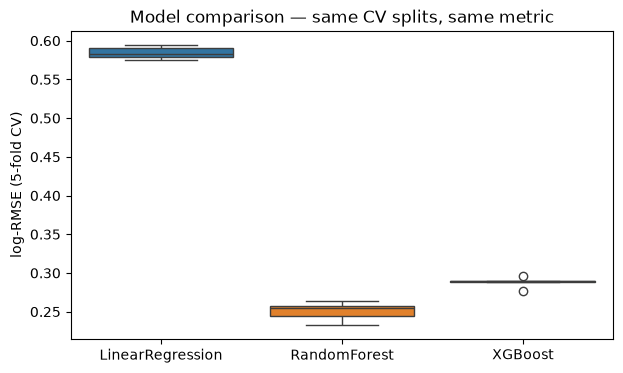

,CV log-RMSE mean,CV log-RMSE std
LinearRegression,0.584271,0.008183
RandomForest,0.250437,0.012008
XGBoost,0.288168,0.006950


In [18]:
results_df = pd.DataFrame({name: scores for name, scores in cv_results.items()})
plt.figure(figsize=(7, 4))
sns.boxplot(data=results_df)
plt.ylabel("log-RMSE (5-fold CV)")
plt.title("Model comparison — same CV splits, same metric")
plt.show()

results_df.agg(["mean", "std"]).T.rename(columns={"mean": "CV log-RMSE mean", "std": "CV log-RMSE std"})

**Result:** Random Forest has the lowest CV log-RMSE and the tightest spread across
folds, XGBoost is close behind, and plain Linear Regression is clearly worse — it can't
capture the non-linear relationships between location/category/size and price. We reported
the **mean ± std across folds**, not just a single number, since a single value would give a
false sense of precision (this is one of the quality checks in the task brief).

We move forward with **Random Forest** for hyperparameter tuning.

## Checkpoint 4 — Hyperparameter Tuning (best model)

We tune Random Forest with `RandomizedSearchCV`, still only on `X_train` / `y_train_log`
(3-fold CV here to keep runtime reasonable, since we're now searching over a grid rather
than evaluating one config).

In [19]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

param_dist = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 1.0],
}

search = RandomizedSearchCV(
    rf_pipe, param_distributions=param_dist, n_iter=8, cv=3,
    scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1, verbose=1,
)
search.fit(X_train, y_train_log)

print("Best params:", search.best_params_)
print("Best CV log-RMSE:", -search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'model__n_estimators': 150, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 20}
Best CV log-RMSE: 0.2677330277715948


## Checkpoint 5 — Final Evaluation on the Test Set (touched once)

This is the **only** time in the whole notebook that `X_test` / `y_test` is used. We take
the best model found by the search above, predict on the held-out test set, and convert
predictions back from log-scale to AZN before computing metrics.

In [20]:
final_model = search.best_estimator_

y_test_pred_log = final_model.predict(X_test)
y_test_pred = np.expm1(y_test_pred_log)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_test_pred) ** 0.5
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)
mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print(f"TEST RMSE : {rmse:,.0f} AZN")
print(f"TEST MAE  : {mae:,.0f} AZN")
print(f"TEST R2   : {r2:.4f}")
print(f"TEST MAPE : {mape:.2f}%")

TEST RMSE : 167,809 AZN
TEST MAE  : 45,746 AZN
TEST R2   : 0.7972
TEST MAPE : 14.37%


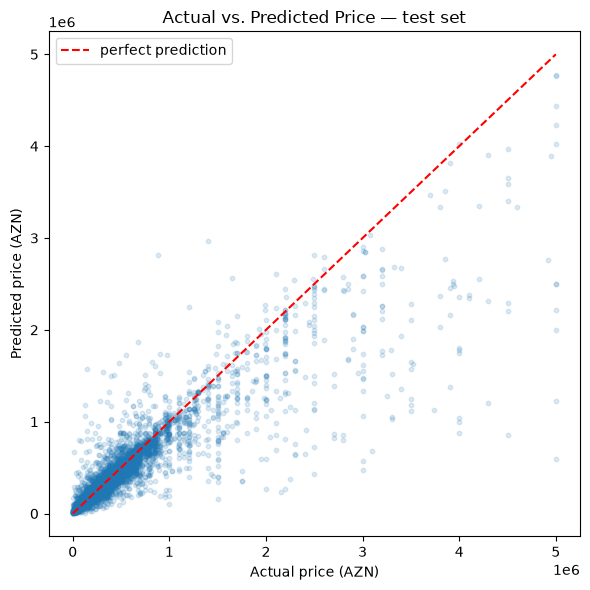

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.15, s=10)
lims = [0, y_test.max()]
plt.plot(lims, lims, color="red", linestyle="--", label="perfect prediction")
plt.xlabel("Actual price (AZN)")
plt.ylabel("Predicted price (AZN)")
plt.title("Actual vs. Predicted Price — test set")
plt.legend()
plt.tight_layout()
plt.show()

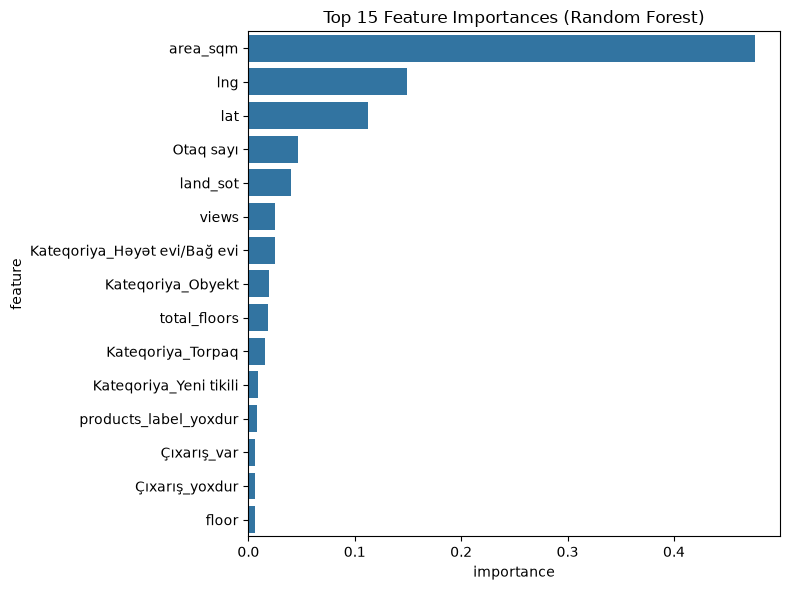

In [22]:
ohe_cols = final_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(cat_features)
all_feature_names = np.concatenate([num_features, ohe_cols])

importances = final_model.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x="importance", y="feature")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

**Interpretation:** area (`area_sqm`) and category/location-related features are the
strongest price drivers, which matches basic real-estate intuition and gives us confidence
the model learned genuine patterns rather than noise or a leaked column.

## Checkpoint 6 — Saving the Model

In [23]:
import joblib

joblib.dump(final_model, "price_model.joblib")
print("Model saved to price_model.joblib")

reloaded = joblib.load("price_model.joblib")
sample_pred = np.expm1(reloaded.predict(X_test.iloc[:3]))
print("Reloaded model sample predictions (AZN):", np.round(sample_pred, 0))

Model saved to price_model.joblib
Reloaded model sample predictions (AZN): [166516. 263390. 472095.]


## Limitations & honest caveats

- The dataset is heavily skewed toward Baku (**99.7%** of listings), so predictions for
  other cities are less reliable — fewer training examples there.
- We removed listings priced under 1,000 AZN or over 5,000,000 AZN as likely data errors;
  this means the model is not meant to price extremely high-end or unusual properties.
- `Otaq sayı` (rooms), `floor`/`total_floors`, and `İpoteka` still have missing values that
  are imputed with the training-fold median/mode — for a production system it would be
  worth investigating *why* these are missing rather than only imputing them.
- Test set was evaluated exactly once, as required — if further changes are made to the
  model, a fresh held-out test set (or at least re-running from a clean split) should be
  used to keep this evaluation honest.